# INS-001.2 Alternative Relevance Metrics: Experimental Evaluation

This notebook evaluates three alternative relevance metrics for INS-001.2 bridging:
1. **Discriminative Relevance** - Can we distinguish the true pair from foil pairs?
2. **Joint Constraint Score** - How well do clues triangulate the endpoints?
3. **Balance Score** - Are clues balanced between anchor and target?

## Goal
Find a relevance metric that:
- Measures whether clues are "on task" (not gibberish)
- Is independent of divergence (target: |r| < 0.30)
- Has meaningful variance across participants
- Is computationally tractable

## Success Criteria

| Metric | Pass Criterion | Rationale |
|--------|----------------|-----------|
| Divergence correlation | \|r\| < 0.30 | Independence from spread |
| Variance | SD > 0.05 (normalized scale) | Meaningful individual differences |
| Distribution | Not degenerate (>90% at one value) | Discriminates across trials |
| A-T correlation | \|r\| < 0.50 | Not purely difficulty-driven |

## Part 1: Setup and Configuration

In [1]:
# Cell 1: Install dependencies and imports
import subprocess
import sys

# Install supabase if not present
try:
    import supabase
except ImportError:
    print("Installing supabase package...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "supabase", "-q"])
    print("supabase installed!")

import os
import json
import random
import asyncio
import time
from datetime import datetime
from itertools import combinations
from pathlib import Path
from typing import Optional, Tuple
from dataclasses import dataclass, field, asdict
from tqdm.auto import tqdm  # auto-detects notebook vs terminal

# External packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway

# API clients (matching INS-001 patterns)
from openai import AsyncOpenAI

# Embeddings (for vocabulary sampling)
import gensim.downloader as gensim_api

# Jupyter async compatibility
import nest_asyncio
nest_asyncio.apply()

print("All imports successful!")

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


In [2]:
# Cell 2: Reproducibility Setup
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Model versions (locked per INS-001 rules)
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"
EMBEDDING_DIMENSIONS = 1536

# Output paths
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# File paths
BRIDGING_RESULTS_PATH = DATA_DIR / "bridging_results.json"
BRIDGING_RAW_PATH = DATA_DIR / "bridging_raw_responses.json"
VOCAB_EMBEDDINGS_PATH = DATA_DIR / "vocab_embeddings.json"
ANALYSIS_RESULTS_PATH = DATA_DIR / "alternative_relevance_analysis.json"

# Experiment parameters (from Part 13 findings)
OPTIMAL_CLUE_COUNT = 4  # Use first 4 clues per trial
N_FOILS = 50  # Number of foil pairs/endpoints for discrimination

# Log experiment metadata
EXPERIMENT_METADATA = {
    "experiment_name": "INS-001.2 Alternative Relevance Metrics",
    "started_at": datetime.now().isoformat(),
    "random_seed": RANDOM_SEED,
    "openai_embedding_model": OPENAI_EMBEDDING_MODEL,
    "optimal_clue_count": OPTIMAL_CLUE_COUNT,
    "n_foils": N_FOILS,
}

print("Experiment metadata:")
for k, v in EXPERIMENT_METADATA.items():
    print(f"  {k}: {v}")

Experiment metadata:
  experiment_name: INS-001.2 Alternative Relevance Metrics
  started_at: 2026-01-18T09:26:21.193284
  random_seed: 42
  openai_embedding_model: text-embedding-3-small
  optimal_clue_count: 4
  n_foils: 50


In [3]:
# Cell 3: API Configuration and Rate Limiting

# Load API keys from secrets file
SECRETS_PATH = Path.home() / "Documents" / "Secrets" / "instruments-keys.env"
if SECRETS_PATH.exists():
    print(f"Loading API keys from {SECRETS_PATH}")
    with open(SECRETS_PATH) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#') and '=' in line:
                key, value = line.split('=', 1)
                # Remove quotes if present
                value = value.strip().strip('"').strip("'")
                os.environ[key] = value
else:
    print(f"Secrets file not found at {SECRETS_PATH}, using environment variables")

# Initialize OpenAI client
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY not found. Set it in environment or in ~/Documents/Secrets/instruments-keys.env")

openai_client = AsyncOpenAI(api_key=OPENAI_API_KEY)

# Initialize Supabase client for vocabulary embeddings
from supabase import create_client  # pip install supabase

SUPABASE_URL = os.environ.get("SUPABASE_URL")
SUPABASE_SERVICE_KEY = os.environ.get("SUPABASE_SERVICE_KEY")

if not SUPABASE_URL or not SUPABASE_SERVICE_KEY:
    raise ValueError("SUPABASE_URL and SUPABASE_SERVICE_KEY required. Add to ~/Documents/Secrets/instruments-keys.env")

supabase_client = create_client(SUPABASE_URL, SUPABASE_SERVICE_KEY)
print("Supabase client initialized successfully!")

# Rate limiting settings (OpenAI: reasonable limits to avoid throttling)
OPENAI_REQUESTS_PER_MINUTE = 500
OPENAI_MIN_DELAY = 60.0 / OPENAI_REQUESTS_PER_MINUTE
_last_openai_request_time = 0.0

def rate_limit_openai():
    """Enforce rate limiting for OpenAI API calls."""
    global _last_openai_request_time
    now = time.time()
    elapsed = now - _last_openai_request_time
    if elapsed < OPENAI_MIN_DELAY:
        sleep_time = OPENAI_MIN_DELAY - elapsed
        time.sleep(sleep_time)
    _last_openai_request_time = time.time()

print(f"Rate limiting enabled: {OPENAI_REQUESTS_PER_MINUTE} req/min")
print("OpenAI client initialized successfully!")

Loading API keys from /Users/vishal/Documents/Secrets/instruments-keys.env
Supabase client initialized successfully!
Rate limiting enabled: 500 req/min
OpenAI client initialized successfully!


In [4]:
# Cell 4: Core Utility Functions

def cosine_similarity(a: list[float], b: list[float]) -> float:
    """Compute cosine similarity between two vectors."""
    a = np.array(a)
    b = np.array(b)
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(dot / (norm_a * norm_b))

async def get_openai_embeddings(texts: list[str]) -> list[list[float]]:
    """
    Get OpenAI embeddings for a list of texts.
    Uses text-embedding-3-small (1536 dimensions).
    Matching INS-001 pattern from embeddings.py.
    """
    rate_limit_openai()
    response = await openai_client.embeddings.create(
        model=OPENAI_EMBEDDING_MODEL,
        input=texts
    )
    return [item.embedding for item in response.data]

def get_openai_embeddings_sync(texts: list[str]) -> list[list[float]]:
    """Synchronous wrapper for OpenAI embeddings."""
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(get_openai_embeddings(texts))

async def get_openai_embeddings_batched(texts: list[str], batch_size: int = 100) -> list[list[float]]:
    """
    Get OpenAI embeddings in batches to handle large lists.
    """
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        embeddings = await get_openai_embeddings(batch)
        all_embeddings.extend(embeddings)
    return all_embeddings

def get_openai_embeddings_batched_sync(texts: list[str], batch_size: int = 100) -> list[list[float]]:
    """Synchronous wrapper for batched embeddings."""
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(get_openai_embeddings_batched(texts, batch_size))

# Test embedding function
test_words = ["dog", "cat", "computer"]
print("Testing OpenAI embedding function...")
test_embs = get_openai_embeddings_sync(test_words)
print(f"  Got {len(test_embs)} embeddings, dim={len(test_embs[0])}")
print(f"  Cosine sim(dog, cat): {cosine_similarity(test_embs[0], test_embs[1]):.3f}")
print(f"  Cosine sim(dog, computer): {cosine_similarity(test_embs[0], test_embs[2]):.3f}")

Testing OpenAI embedding function...
  Got 3 embeddings, dim=1536
  Cosine sim(dog, cat): 0.603
  Cosine sim(dog, computer): 0.343


## Part 2: Data Loading and Embedding Augmentation

In [5]:
# Cell 5: Load Existing Bridging Results

print("Loading bridging results...")

if not BRIDGING_RESULTS_PATH.exists():
    raise FileNotFoundError(f"Bridging results not found at {BRIDGING_RESULTS_PATH}")

with open(BRIDGING_RESULTS_PATH, "r") as f:
    bridging_data = json.load(f)

print(f"Loaded {len(bridging_data)} total trials")

# Filter to valid trials only
valid_trials = [t for t in bridging_data if t.get("valid", False)]
print(f"Valid trials: {len(valid_trials)}")

# Display sample trial structure
print("\nSample trial structure:")
sample = valid_trials[0]
for key, value in sample.items():
    if isinstance(value, list):
        print(f"  {key}: [{len(value)} items] e.g., {value[:3]}...")
    else:
        print(f"  {key}: {value}")

Loading bridging results...
Loaded 500 total trials
Valid trials: 116

Sample trial structure:
  trial_id: bridge_t0.0_p4
  anchor: in
  target: wadi
  clues: [10 items] e.g., ['desert', 'valley', 'water']...
  temperature: 0.0
  relevance: 0.08319240994751453
  divergence: 77.17470963005766
  valid: True


In [6]:
# Cell 6: Compute or Load Embeddings for Trials

def load_or_compute_trial_embeddings(trials: list[dict], cache_path: Path) -> list[dict]:
    """
    Load cached trial embeddings or compute them via OpenAI API.
    
    Adds to each trial:
    - anchor_embedding: list[float]
    - target_embedding: list[float]  
    - clue_embeddings: list[list[float]] (for first OPTIMAL_CLUE_COUNT clues)
    - at_distance: float (anchor-target cosine distance)
    """
    # Check for cached data
    if cache_path.exists():
        print(f"Loading cached embeddings from {cache_path}")
        with open(cache_path, "r") as f:
            cached = json.load(f)
        # Verify cache matches current trials
        if len(cached) == len(trials):
            return cached
        else:
            print(f"Cache size mismatch ({len(cached)} vs {len(trials)}), recomputing...")
    
    print(f"Computing embeddings for {len(trials)} trials...")
    
    # Collect all unique words that need embeddings
    all_words = set()
    for trial in trials:
        all_words.add(trial["anchor"])
        all_words.add(trial["target"])
        for clue in trial["clues"][:OPTIMAL_CLUE_COUNT]:
            all_words.add(clue)
    
    word_list = sorted(all_words)
    print(f"  Unique words to embed: {len(word_list)}")
    
    # Get embeddings in batches
    print("  Fetching embeddings from OpenAI API...")
    embeddings_list = get_openai_embeddings_batched_sync(word_list, batch_size=100)
    
    # Create word -> embedding mapping
    word_to_embedding = {word: emb for word, emb in zip(word_list, embeddings_list)}
    print(f"  Got {len(word_to_embedding)} embeddings")
    
    # Augment trials with embeddings
    augmented_trials = []
    for trial in tqdm(trials, desc="Augmenting trials"):
        anchor_emb = word_to_embedding.get(trial["anchor"], [0.0] * EMBEDDING_DIMENSIONS)
        target_emb = word_to_embedding.get(trial["target"], [0.0] * EMBEDDING_DIMENSIONS)
        
        clue_embs = []
        for clue in trial["clues"][:OPTIMAL_CLUE_COUNT]:
            emb = word_to_embedding.get(clue, [0.0] * EMBEDDING_DIMENSIONS)
            clue_embs.append(emb)
        
        # Compute A-T distance
        at_distance = 1 - cosine_similarity(anchor_emb, target_emb)
        
        augmented = {
            **trial,
            "anchor_embedding": anchor_emb,
            "target_embedding": target_emb,
            "clue_embeddings": clue_embs,
            "at_distance": at_distance,
            "current_relevance": trial.get("relevance", 0.0),
            "current_divergence": trial.get("divergence", 0.0),
        }
        augmented_trials.append(augmented)
    
    # Cache the augmented data
    print(f"Saving to cache: {cache_path}")
    with open(cache_path, "w") as f:
        json.dump(augmented_trials, f)
    
    return augmented_trials

# Load or compute embeddings
trials_with_embeddings = load_or_compute_trial_embeddings(valid_trials, BRIDGING_RAW_PATH)
print(f"\nReady: {len(trials_with_embeddings)} trials with embeddings")

Loading cached embeddings from data/bridging_raw_responses.json

Ready: 116 trials with embeddings


In [7]:
# Cell 7: Verify Embedding Data Structure

print("=== Data Verification ===\n")

sample = trials_with_embeddings[0]
print(f"Sample trial: {sample['anchor']} → {sample['target']}")
print(f"  Clues (first {OPTIMAL_CLUE_COUNT}): {sample['clues'][:OPTIMAL_CLUE_COUNT]}")
print(f"  Anchor embedding dim: {len(sample['anchor_embedding'])}")
print(f"  Target embedding dim: {len(sample['target_embedding'])}")
print(f"  Clue embeddings: {len(sample['clue_embeddings'])} x {len(sample['clue_embeddings'][0])}")
print(f"  A-T distance: {sample['at_distance']:.4f}")
print(f"  Current relevance: {sample['current_relevance']:.4f}")
print(f"  Current divergence: {sample['current_divergence']:.2f}")

# Summary statistics
at_distances = [t["at_distance"] for t in trials_with_embeddings]
current_relevances = [t["current_relevance"] for t in trials_with_embeddings]
current_divergences = [t["current_divergence"] for t in trials_with_embeddings]

print(f"\n--- Distribution Summary ---")
print(f"A-T distance:      mean={np.mean(at_distances):.3f}, std={np.std(at_distances):.3f}")
print(f"Current relevance: mean={np.mean(current_relevances):.3f}, std={np.std(current_relevances):.3f}")
print(f"Current divergence: mean={np.mean(current_divergences):.1f}, std={np.std(current_divergences):.1f}")

=== Data Verification ===

Sample trial: in → wadi
  Clues (first 4): ['desert', 'valley', 'water', 'riverbed']
  Anchor embedding dim: 1536
  Target embedding dim: 1536
  Clue embeddings: 4 x 1536
  A-T distance: 0.7283
  Current relevance: 0.0832
  Current divergence: 77.17

--- Distribution Summary ---
A-T distance:      mean=0.754, std=0.054
Current relevance: mean=0.103, std=0.048
Current divergence: mean=76.9, std=5.1


## Part 3: Vocabulary Embeddings for Foil Generation

In [8]:
# Cell 8: Load GloVe for Vocabulary Sampling

print("Loading GloVe model for vocabulary sampling...")
print("(This is used to identify common English words, not for final embeddings)")

GLOVE_MODEL_NAME = "glove-wiki-gigaword-300"
glove = gensim_api.load(GLOVE_MODEL_NAME)
glove_vocab = list(glove.key_to_index.keys())

print(f"GloVe loaded: {len(glove_vocab):,} words")

# Sample common words (top N by frequency in GloVe = lower index)
VOCAB_SIZE = 5000
common_words = glove_vocab[:VOCAB_SIZE]
print(f"Selected top {VOCAB_SIZE} common words for vocabulary")

Loading GloVe model for vocabulary sampling...
(This is used to identify common English words, not for final embeddings)
GloVe loaded: 400,000 words
Selected top 5000 common words for vocabulary


In [11]:
# Cell 9: Load Vocabulary Embeddings from Supabase

def load_vocab_embeddings_from_supabase(
    supabase, 
    target_words: list[str] = None,
    cache_path: Path = None,
    limit: int = 5000
) -> dict[str, list[float]]:
    """
    Load vocabulary embeddings from Supabase vocabulary_embeddings table.
    
    Args:
        supabase: Supabase client
        target_words: Optional list of specific words to fetch
        cache_path: Optional path to cache results locally
        limit: Max words to fetch if target_words not specified
    
    Returns: Dict mapping word -> embedding
    """
    # Check cache first
    if cache_path and cache_path.exists():
        print(f"Loading cached vocabulary embeddings from {cache_path}")
        with open(cache_path, "r") as f:
            vocab_embeddings = json.load(f)
        print(f"  Loaded {len(vocab_embeddings)} embeddings from cache")
        return vocab_embeddings
    
    print("Fetching vocabulary embeddings from Supabase...")
    
    vocab_embeddings = {}
    batch_size = 1000
    offset = 0
    
    while True:
        # Fetch batch from Supabase
        if target_words:
            # Fetch specific words in batches
            batch_words = target_words[offset:offset + batch_size]
            if not batch_words:
                break
            result = supabase.table("vocabulary_embeddings") \
                .select("word, embedding") \
                .in_("word", batch_words) \
                .execute()
        else:
            # Fetch by frequency rank
            result = supabase.table("vocabulary_embeddings") \
                .select("word, embedding") \
                .order("frequency_rank") \
                .range(offset, offset + batch_size - 1) \
                .execute()
        
        if not result.data:
            break
        
        for row in result.data:
            word = row["word"]
            embedding = row["embedding"]
            
            # Parse embedding if it's a string (halfvec returns as string)
            if isinstance(embedding, str):
                # halfvec format: "[0.1,0.2,...]"
                try:
                    embedding = json.loads(embedding)
                except json.JSONDecodeError:
                    # Try parsing as comma-separated values
                    embedding = [float(x) for x in embedding.strip("[]").split(",")]
            
            if isinstance(embedding, list) and len(embedding) == 1536:
                vocab_embeddings[word] = embedding
        
        print(f"  Fetched {len(vocab_embeddings)} embeddings...")
        
        offset += batch_size
        
        if target_words:
            if offset >= len(target_words):
                break
        else:
            if len(vocab_embeddings) >= limit or len(result.data) < batch_size:
                break
    
    print(f"  Total: {len(vocab_embeddings)} embeddings")
    
    # Cache locally for future runs
    if cache_path:
        print(f"Saving to cache: {cache_path}")
        with open(cache_path, "w") as f:
            json.dump(vocab_embeddings, f)
    
    return vocab_embeddings

# Load vocabulary embeddings from Supabase
vocabulary_embeddings = load_vocab_embeddings_from_supabase(
    supabase_client,
    target_words=common_words,  # Use the common words from GloVe
    cache_path=VOCAB_EMBEDDINGS_PATH,
    limit=VOCAB_SIZE
)

print(f"\nVocabulary ready: {len(vocabulary_embeddings)} words with embeddings")

Fetching vocabulary embeddings from Supabase...
  Fetched 888 embeddings...
  Fetched 1828 embeddings...
  Fetched 2761 embeddings...
  Fetched 3687 embeddings...
  Fetched 4597 embeddings...
  Total: 4597 embeddings
Saving to cache: data/vocab_embeddings.json

Vocabulary ready: 4597 words with embeddings


In [12]:
# Cell 10: Verify Vocabulary Embeddings

print("=== Vocabulary Embedding Verification ===\n")

# Sample words
sample_words = ["dog", "cat", "computer", "music", "science"]
print("Sample similarities:")
for i, w1 in enumerate(sample_words):
    for w2 in sample_words[i+1:]:
        if w1 in vocabulary_embeddings and w2 in vocabulary_embeddings:
            sim = cosine_similarity(vocabulary_embeddings[w1], vocabulary_embeddings[w2])
            print(f"  {w1} ↔ {w2}: {sim:.3f}")

# Check embedding dimensions
sample_emb = list(vocabulary_embeddings.values())[0]
print(f"\nEmbedding dimensions: {len(sample_emb)}")

# Convert to numpy arrays for faster computation
vocab_words = list(vocabulary_embeddings.keys())
vocab_embs = np.array(list(vocabulary_embeddings.values()))
print(f"Vocabulary matrix shape: {vocab_embs.shape}")

=== Vocabulary Embedding Verification ===

Sample similarities:
  dog ↔ computer: 0.343
  dog ↔ music: 0.258
  dog ↔ science: 0.299
  computer ↔ music: 0.355
  computer ↔ science: 0.394
  music ↔ science: 0.485

Embedding dimensions: 1536
Vocabulary matrix shape: (4597, 1536)


## Part 4: Core Metric Implementations

In [13]:
# Cell 11: Approach 1 - Discriminative Relevance

def generate_foil_pairs(
    anchor_embedding: list[float],
    target_embedding: list[float],
    vocabulary_embeddings: dict[str, list[float]],
    n_foils: int = 50,
    match_difficulty: bool = True,
    seed: int = 42
) -> list[Tuple[list[float], list[float]]]:
    """
    Generate foil pairs for discrimination testing.
    
    Args:
        anchor_embedding: True anchor embedding
        target_embedding: True target embedding
        vocabulary_embeddings: Dict mapping words to embeddings
        n_foils: Number of foil pairs to generate
        match_difficulty: If True, match foils on A-T distance
        seed: Random seed
        
    Returns:
        List of (foil_anchor_emb, foil_target_emb) tuples
    """
    rng = np.random.default_rng(seed)
    vocab_words = list(vocabulary_embeddings.keys())
    vocab_embs = [vocabulary_embeddings[w] for w in vocab_words]
    
    true_at_distance = 1 - cosine_similarity(anchor_embedding, target_embedding)
    
    foil_pairs = []
    attempts = 0
    max_attempts = n_foils * 100
    
    while len(foil_pairs) < n_foils and attempts < max_attempts:
        attempts += 1
        
        # Sample two random words
        idx1, idx2 = rng.choice(len(vocab_words), size=2, replace=False)
        foil_a = vocab_embs[idx1]
        foil_t = vocab_embs[idx2]
        
        if match_difficulty:
            # Check if A-T distance is within tolerance
            foil_distance = 1 - cosine_similarity(foil_a, foil_t)
            tolerance = 0.05  # Allow 5% deviation
            if abs(foil_distance - true_at_distance) > tolerance:
                continue
        
        foil_pairs.append((foil_a, foil_t))
    
    # If we couldn't match difficulty, fall back to random
    if len(foil_pairs) < n_foils:
        # Silently fill remainder with random pairs
        while len(foil_pairs) < n_foils:
            idx1, idx2 = rng.choice(len(vocab_words), size=2, replace=False)
            foil_pairs.append((vocab_embs[idx1], vocab_embs[idx2]))
    
    return foil_pairs


def discriminative_relevance(
    clue_embeddings: list[list[float]],
    anchor_embedding: list[float],
    target_embedding: list[float],
    foil_pairs: list[Tuple[list[float], list[float]]],
) -> dict:
    """
    Measure how well clues discriminate the true pair from foil pairs.
    
    Args:
        clue_embeddings: Embeddings for participant's clues
        anchor_embedding: True anchor embedding
        target_embedding: True target embedding
        foil_pairs: List of (foil_anchor_emb, foil_target_emb) tuples
        
    Returns:
        Dictionary with:
        - percentile_rank: Where true pair ranks among all pairs (0-1)
        - discrimination_score: Normalized discrimination ability
        - true_pair_fit: Raw fit score for true pair
        - foil_mean_fit: Mean fit score for foils
        - foil_std_fit: Std of foil fit scores
    """
    def pair_fit(clues, anchor, target):
        """
        Compute how well clues fit a given anchor-target pair.
        Using mean of min(sim_anchor, sim_target) per clue.
        This captures "bridging" quality - clues must relate to BOTH endpoints.
        """
        fits = []
        for clue in clues:
            sim_a = cosine_similarity(clue, anchor)
            sim_t = cosine_similarity(clue, target)
            fits.append(min(sim_a, sim_t))
        return np.mean(fits) if fits else 0.0
    
    # Score true pair
    true_fit = pair_fit(clue_embeddings, anchor_embedding, target_embedding)
    
    # Score all foil pairs
    foil_fits = [pair_fit(clue_embeddings, fa, ft) for fa, ft in foil_pairs]
    
    # Compute percentile rank
    rank = sum(true_fit > f for f in foil_fits)
    percentile_rank = rank / len(foil_fits) if foil_fits else 0.0
    
    # Compute z-score style discrimination
    foil_mean = np.mean(foil_fits) if foil_fits else 0.0
    foil_std = np.std(foil_fits) if foil_fits else 0.0
    if foil_std > 0:
        discrimination_score = (true_fit - foil_mean) / foil_std
    else:
        discrimination_score = 0.0
    
    return {
        "percentile_rank": float(percentile_rank),
        "discrimination_score": float(discrimination_score),
        "true_pair_fit": float(true_fit),
        "foil_mean_fit": float(foil_mean),
        "foil_std_fit": float(foil_std)
    }

print("Approach 1: Discriminative Relevance implemented")

Approach 1: Discriminative Relevance implemented


In [14]:
# Cell 12: Approach 4 - Joint Constraint Score

def generate_endpoint_foils(
    endpoint_embedding: list[float],
    vocabulary_embeddings: dict[str, list[float]],
    n_foils: int = 50,
    method: str = "nearest_neighbors"
) -> list[list[float]]:
    """
    Generate foil endpoints for constraint analysis.
    
    Args:
        endpoint_embedding: True endpoint (anchor or target)
        vocabulary_embeddings: Dict mapping words to embeddings
        n_foils: Number of foils to generate
        method: "nearest_neighbors" (hard foils) or "random" (easy foils)
        
    Returns:
        List of foil embeddings
    """
    vocab_embs = list(vocabulary_embeddings.values())
    
    if method == "nearest_neighbors":
        # Use nearest neighbors as hard-to-distinguish foils
        similarities = [cosine_similarity(endpoint_embedding, v) for v in vocab_embs]
        sorted_indices = np.argsort(similarities)[::-1]  # Descending
        # Skip the top match (might be the word itself)
        foil_indices = sorted_indices[1:n_foils+1]
        return [vocab_embs[i] for i in foil_indices]
    
    elif method == "random":
        # Random sampling for baseline comparison
        rng = np.random.default_rng(42)
        indices = rng.choice(len(vocab_embs), size=n_foils, replace=False)
        return [vocab_embs[i] for i in indices]
    
    else:
        raise ValueError(f"Unknown method: {method}")


def joint_constraint_score(
    clue_embeddings: list[list[float]],
    anchor_embedding: list[float],
    target_embedding: list[float],
    foil_anchors: list[list[float]],
    foil_targets: list[list[float]],
) -> dict:
    """
    Measure how well clues jointly constrain the solution space.
    
    A foil is "eliminated" by a clue if that clue is more similar to the
    true endpoint than to the foil. Good clue sets have:
    - High coverage: Most foils eliminated by at least one clue
    - High efficiency: Clues eliminate different foils (non-redundant)
    
    Args:
        clue_embeddings: Embeddings for participant's clues
        anchor_embedding: True anchor embedding
        target_embedding: True target embedding
        foil_anchors: Alternative anchor embeddings
        foil_targets: Alternative target embeddings
        
    Returns:
        Dictionary with coverage, efficiency, and joint score metrics
    """
    def get_eliminations(clue_emb, true_emb, foil_embs):
        """Return set of foil indices eliminated by this clue."""
        true_sim = cosine_similarity(clue_emb, true_emb)
        eliminated = set()
        for i, foil in enumerate(foil_embs):
            foil_sim = cosine_similarity(clue_emb, foil)
            if true_sim > foil_sim:
                eliminated.add(i)
        return eliminated
    
    # Compute eliminations for each clue
    anchor_elims = [get_eliminations(c, anchor_embedding, foil_anchors) 
                    for c in clue_embeddings]
    target_elims = [get_eliminations(c, target_embedding, foil_targets) 
                    for c in clue_embeddings]
    
    # Coverage: fraction of foils eliminated by at least one clue
    if foil_anchors and anchor_elims:
        anchor_union = set.union(*anchor_elims) if anchor_elims else set()
        anchor_coverage = len(anchor_union) / len(foil_anchors)
    else:
        anchor_coverage = 0.0
        
    if foil_targets and target_elims:
        target_union = set.union(*target_elims) if target_elims else set()
        target_coverage = len(target_union) / len(foil_targets)
    else:
        target_coverage = 0.0
    
    # Efficiency: 1 - (intersection / union)
    # High efficiency = clues eliminate different foils
    def compute_efficiency(elim_sets):
        if len(elim_sets) < 2:
            return 1.0
        union = set.union(*elim_sets)
        if not union:
            return 0.0
        intersection = set.intersection(*elim_sets)
        redundancy = len(intersection) / len(union)
        return 1 - redundancy
    
    anchor_efficiency = compute_efficiency(anchor_elims)
    target_efficiency = compute_efficiency(target_elims)
    
    # Combined metrics
    overall_coverage = (anchor_coverage + target_coverage) / 2
    overall_efficiency = (anchor_efficiency + target_efficiency) / 2
    joint_score = overall_coverage * overall_efficiency
    
    return {
        "anchor_coverage": float(anchor_coverage),
        "target_coverage": float(target_coverage),
        "anchor_efficiency": float(anchor_efficiency),
        "target_efficiency": float(target_efficiency),
        "overall_coverage": float(overall_coverage),
        "overall_efficiency": float(overall_efficiency),
        "joint_score": float(joint_score)
    }

print("Approach 4: Joint Constraint Score implemented")

Approach 4: Joint Constraint Score implemented


In [15]:
# Cell 13: Approach 5 - Balance Score

def balance_score(
    clue_embeddings: list[list[float]],
    anchor_embedding: list[float],
    target_embedding: list[float],
) -> dict:
    """
    Measure how balanced clues are between anchor and target.
    
    Perfect balance: half the clues lean toward anchor, half toward target.
    Unbalanced: all clues cluster near one endpoint.
    
    Args:
        clue_embeddings: Embeddings for participant's clues
        anchor_embedding: Anchor embedding
        target_embedding: Target embedding
        
    Returns:
        Dictionary with:
        - balance: 0 (all one side) to 1 (perfectly balanced)
        - mean_bias: Average lean toward anchor (positive) or target (negative)
        - bias_std: Standard deviation of biases
        - floor_attention: Mean of min(sim_a, sim_t) per clue
        - individual_biases: Per-clue bias values
    """
    biases = []
    floor_attentions = []
    
    for clue in clue_embeddings:
        sim_a = cosine_similarity(clue, anchor_embedding)
        sim_t = cosine_similarity(clue, target_embedding)
        
        # Bias: positive = closer to anchor, negative = closer to target
        bias = sim_a - sim_t
        biases.append(bias)
        
        # Floor attention: minimum similarity to either endpoint
        floor_attentions.append(min(sim_a, sim_t))
    
    mean_bias = np.mean(biases) if biases else 0.0
    bias_std = np.std(biases) if biases else 0.0
    
    # Balance score: 1 - |mean_bias| normalized
    # Normalize by max possible bias (which is ~1 for opposite directions)
    balance = 1 - abs(mean_bias)
    
    # Alternative: count-based balance
    n_anchor_leaning = sum(b > 0 for b in biases)
    n_target_leaning = sum(b < 0 for b in biases)
    n_total = len(biases)
    count_balance = 1 - abs(n_anchor_leaning - n_target_leaning) / n_total if n_total > 0 else 0.0
    
    return {
        "balance": float(balance),
        "count_balance": float(count_balance),
        "mean_bias": float(mean_bias),
        "bias_std": float(bias_std),
        "floor_attention": float(np.mean(floor_attentions)) if floor_attentions else 0.0,
        "individual_biases": [float(b) for b in biases]
    }

print("Approach 5: Balance Score implemented")

Approach 5: Balance Score implemented


In [16]:
# Cell 14: Test Metric Implementations

print("=== Testing Metric Implementations ===\n")

# Use first trial as test case
test_trial = trials_with_embeddings[0]
print(f"Test trial: {test_trial['anchor']} → {test_trial['target']}")
print(f"Clues: {test_trial['clues'][:OPTIMAL_CLUE_COUNT]}")

# Test Approach 1: Discriminative Relevance
print("\n--- Approach 1: Discriminative Relevance ---")
foil_pairs = generate_foil_pairs(
    test_trial["anchor_embedding"],
    test_trial["target_embedding"],
    vocabulary_embeddings,
    n_foils=N_FOILS,
    match_difficulty=True
)
print(f"Generated {len(foil_pairs)} foil pairs")

disc_result = discriminative_relevance(
    test_trial["clue_embeddings"],
    test_trial["anchor_embedding"],
    test_trial["target_embedding"],
    foil_pairs
)
print(f"Percentile rank: {disc_result['percentile_rank']:.3f}")
print(f"Discrimination score: {disc_result['discrimination_score']:.3f}")
print(f"True pair fit: {disc_result['true_pair_fit']:.3f}")

# Test Approach 4: Joint Constraint
print("\n--- Approach 4: Joint Constraint ---")
foil_anchors = generate_endpoint_foils(
    test_trial["anchor_embedding"],
    vocabulary_embeddings,
    n_foils=N_FOILS,
    method="nearest_neighbors"
)
foil_targets = generate_endpoint_foils(
    test_trial["target_embedding"],
    vocabulary_embeddings,
    n_foils=N_FOILS,
    method="nearest_neighbors"
)
print(f"Generated {len(foil_anchors)} anchor foils, {len(foil_targets)} target foils")

constraint_result = joint_constraint_score(
    test_trial["clue_embeddings"],
    test_trial["anchor_embedding"],
    test_trial["target_embedding"],
    foil_anchors,
    foil_targets
)
print(f"Overall coverage: {constraint_result['overall_coverage']:.3f}")
print(f"Overall efficiency: {constraint_result['overall_efficiency']:.3f}")
print(f"Joint score: {constraint_result['joint_score']:.3f}")

# Test Approach 5: Balance
print("\n--- Approach 5: Balance ---")
balance_result = balance_score(
    test_trial["clue_embeddings"],
    test_trial["anchor_embedding"],
    test_trial["target_embedding"]
)
print(f"Balance: {balance_result['balance']:.3f}")
print(f"Count balance: {balance_result['count_balance']:.3f}")
print(f"Mean bias: {balance_result['mean_bias']:.3f}")
print(f"Floor attention: {balance_result['floor_attention']:.3f}")

print("\n✓ All metric implementations working correctly")

=== Testing Metric Implementations ===

Test trial: in → wadi
Clues: ['desert', 'valley', 'water', 'riverbed']

--- Approach 1: Discriminative Relevance ---
Generated 50 foil pairs
Percentile rank: 0.980
Discrimination score: 2.084
True pair fit: 0.262

--- Approach 4: Joint Constraint ---
Generated 50 anchor foils, 50 target foils
Overall coverage: 0.860
Overall efficiency: 0.621
Joint score: 0.534

--- Approach 5: Balance ---
Balance: 0.799
Count balance: 0.000
Mean bias: -0.201
Floor attention: 0.262

✓ All metric implementations working correctly


## Part 5: Compute All Metrics

In [17]:
# Cell 15: Compute All Metrics for All Trials

print(f"Computing metrics for {len(trials_with_embeddings)} trials...")
print(f"Using {OPTIMAL_CLUE_COUNT} clues per trial")
print(f"Foil count: {N_FOILS}\n")

results = []

for trial in tqdm(trials_with_embeddings, desc="Computing metrics"):
    # Existing metrics
    existing = {
        "trial_id": trial["trial_id"],
        "anchor": trial["anchor"],
        "target": trial["target"],
        "temperature": trial.get("temperature", 0.0),
        "relevance_current": trial["current_relevance"],
        "divergence_current": trial["current_divergence"],
        "at_distance": trial["at_distance"]
    }
    
    # Approach 1: Discriminative Relevance
    foil_pairs = generate_foil_pairs(
        trial["anchor_embedding"],
        trial["target_embedding"],
        vocabulary_embeddings,
        n_foils=N_FOILS,
        match_difficulty=True,
        seed=RANDOM_SEED + hash(trial["trial_id"]) % 10000  # Per-trial seed
    )
    disc = discriminative_relevance(
        trial["clue_embeddings"],
        trial["anchor_embedding"],
        trial["target_embedding"],
        foil_pairs
    )
    
    # Approach 4: Joint Constraint
    foil_anchors = generate_endpoint_foils(
        trial["anchor_embedding"],
        vocabulary_embeddings,
        n_foils=N_FOILS,
        method="nearest_neighbors"
    )
    foil_targets = generate_endpoint_foils(
        trial["target_embedding"],
        vocabulary_embeddings,
        n_foils=N_FOILS,
        method="nearest_neighbors"
    )
    constraint = joint_constraint_score(
        trial["clue_embeddings"],
        trial["anchor_embedding"],
        trial["target_embedding"],
        foil_anchors,
        foil_targets
    )
    
    # Approach 5: Balance
    balance = balance_score(
        trial["clue_embeddings"],
        trial["anchor_embedding"],
        trial["target_embedding"]
    )
    
    # Combine all results (excluding individual_biases to keep DataFrame clean)
    result = {
        **existing,
        "disc_percentile_rank": disc["percentile_rank"],
        "disc_discrimination_score": disc["discrimination_score"],
        "disc_true_pair_fit": disc["true_pair_fit"],
        "disc_foil_mean_fit": disc["foil_mean_fit"],
        "constraint_anchor_coverage": constraint["anchor_coverage"],
        "constraint_target_coverage": constraint["target_coverage"],
        "constraint_anchor_efficiency": constraint["anchor_efficiency"],
        "constraint_target_efficiency": constraint["target_efficiency"],
        "constraint_overall_coverage": constraint["overall_coverage"],
        "constraint_overall_efficiency": constraint["overall_efficiency"],
        "constraint_joint_score": constraint["joint_score"],
        "balance_balance": balance["balance"],
        "balance_count_balance": balance["count_balance"],
        "balance_mean_bias": balance["mean_bias"],
        "balance_bias_std": balance["bias_std"],
        "balance_floor_attention": balance["floor_attention"],
    }
    results.append(result)

# Convert to DataFrame
df = pd.DataFrame(results)
print(f"\n✓ Computed metrics for {len(df)} trials")
print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Computing metrics for 116 trials...
Using 4 clues per trial
Foil count: 50



Computing metrics: 100%|██████████| 116/116 [01:09<00:00,  1.67it/s]


✓ Computed metrics for 116 trials
DataFrame shape: (116, 23)
Columns: ['trial_id', 'anchor', 'target', 'temperature', 'relevance_current', 'divergence_current', 'at_distance', 'disc_percentile_rank', 'disc_discrimination_score', 'disc_true_pair_fit', 'disc_foil_mean_fit', 'constraint_anchor_coverage', 'constraint_target_coverage', 'constraint_anchor_efficiency', 'constraint_target_efficiency', 'constraint_overall_coverage', 'constraint_overall_efficiency', 'constraint_joint_score', 'balance_balance', 'balance_count_balance', 'balance_mean_bias', 'balance_bias_std', 'balance_floor_attention']


## Part 6: Correlation Analysis

In [18]:
# Cell 17: Correlation Analysis

print("=== Correlation Analysis ===\n")

# Metrics to test against divergence
metrics_to_test = [
    "disc_percentile_rank",
    "disc_discrimination_score",
    "constraint_joint_score",
    "constraint_overall_coverage",
    "constraint_overall_efficiency",
    "balance_balance",
    "balance_count_balance"
]

# Primary success criterion: |r| < 0.30 with divergence
print("=== Correlation with Divergence ===")
print("Target: |r| < 0.30 for independence")
print("-" * 65)

divergence_correlations = {}
for metric in metrics_to_test:
    r, p = pearsonr(df[metric], df["divergence_current"])
    status = "✓ PASS" if abs(r) < 0.30 else "✗ FAIL"
    divergence_correlations[metric] = {"r": r, "p": p, "passed": abs(r) < 0.30}
    print(f"{metric:35} r={r:+.3f}, p={p:.4f} {status}")

# Correlation with current relevance
print("\n=== Correlation with Current Relevance ===")
print("(High correlation expected if measuring similar construct)")
print("-" * 65)

relevance_correlations = {}
for metric in metrics_to_test:
    r, p = pearsonr(df[metric], df["relevance_current"])
    relevance_correlations[metric] = {"r": r, "p": p}
    print(f"{metric:35} r={r:+.3f}, p={p:.4f}")

# Correlation with A-T distance (difficulty confounding check)
print("\n=== Correlation with A-T Distance ===")
print("(Check for difficulty confounding, target: |r| < 0.50)")
print("-" * 65)

at_distance_correlations = {}
for metric in metrics_to_test:
    r, p = pearsonr(df[metric], df["at_distance"])
    status = "✓ OK" if abs(r) < 0.50 else "⚠ CONCERN"
    at_distance_correlations[metric] = {"r": r, "p": p, "ok": abs(r) < 0.50}
    print(f"{metric:35} r={r:+.3f}, p={p:.4f} {status}")

=== Correlation Analysis ===

=== Correlation with Divergence ===
Target: |r| < 0.30 for independence
-----------------------------------------------------------------
disc_percentile_rank                r=-0.113, p=0.2271 ✓ PASS
disc_discrimination_score           r=-0.126, p=0.1773 ✓ PASS
constraint_joint_score              r=+0.055, p=0.5597 ✓ PASS
constraint_overall_coverage         r=-0.068, p=0.4654 ✓ PASS
constraint_overall_efficiency       r=+0.130, p=0.1643 ✓ PASS
balance_balance                     r=-0.162, p=0.0816 ✓ PASS
balance_count_balance               r=-0.239, p=0.0098 ✓ PASS

=== Correlation with Current Relevance ===
(High correlation expected if measuring similar construct)
-----------------------------------------------------------------
disc_percentile_rank                r=+0.311, p=0.0007
disc_discrimination_score           r=+0.362, p=0.0001
constraint_joint_score              r=-0.238, p=0.0102
constraint_overall_coverage         r=+0.009, p=0.9239
constrain

=== Metric Cross-Correlations ===



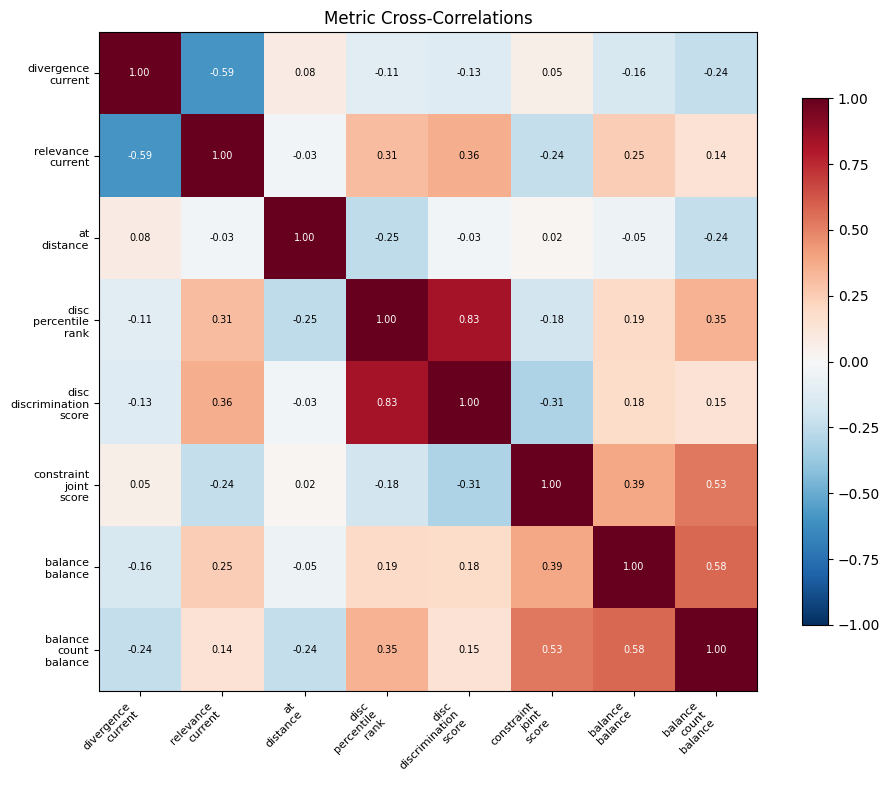

Saved to figures/metric_correlations.png


In [19]:
# Cell 18: Cross-correlation Matrix

print("=== Metric Cross-Correlations ===\n")

# Build correlation matrix for key metrics
corr_metrics = [
    "divergence_current",
    "relevance_current", 
    "at_distance",
    "disc_percentile_rank",
    "disc_discrimination_score",
    "constraint_joint_score",
    "balance_balance",
    "balance_count_balance"
]

corr_matrix = df[corr_metrics].corr()

# Display as heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

# Add labels
ax.set_xticks(range(len(corr_metrics)))
ax.set_yticks(range(len(corr_metrics)))
ax.set_xticklabels([m.replace("_", "\n") for m in corr_metrics], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([m.replace("_", "\n") for m in corr_metrics], fontsize=8)

# Add correlation values
for i in range(len(corr_metrics)):
    for j in range(len(corr_metrics)):
        text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black" if abs(corr_matrix.iloc[i, j]) < 0.5 else "white",
                       fontsize=7)

ax.set_title("Metric Cross-Correlations")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "metric_correlations.png", dpi=150)
plt.show()

print(f"Saved to {FIGURES_DIR / 'metric_correlations.png'}")

## Part 7: Distribution Analysis

In [20]:
# Cell 19: Distribution Statistics

print("=== Distribution Statistics ===\n")
print("-" * 75)
print(f"{'Metric':35} {'Mean':>8} {'SD':>8} {'Min':>8} {'Max':>8} {'Range':>8}")
print("-" * 75)

distribution_stats = {}
for metric in metrics_to_test:
    mean_val = df[metric].mean()
    std_val = df[metric].std()
    min_val = df[metric].min()
    max_val = df[metric].max()
    range_val = max_val - min_val
    
    distribution_stats[metric] = {
        "mean": mean_val,
        "std": std_val,
        "min": min_val,
        "max": max_val,
        "range": range_val
    }
    
    print(f"{metric:35} {mean_val:8.3f} {std_val:8.3f} {min_val:8.3f} {max_val:8.3f} {range_val:8.3f}")

# Check for degenerate distributions
print("\n--- Degeneracy Check ---")
print("Criterion: SD > 0.05 for normalized metrics, distribution not concentrated at single value")

for metric in metrics_to_test:
    values = df[metric]
    std_val = values.std()
    # Check if >90% at a single value (binned)
    hist, bin_edges = np.histogram(values, bins=10)
    max_concentration = hist.max() / len(values)
    
    passed = std_val > 0.05 and max_concentration < 0.90
    status = "✓ PASS" if passed else "✗ FAIL"
    print(f"{metric:35} SD={std_val:.3f}, max_bin={max_concentration:.1%} {status}")

=== Distribution Statistics ===

---------------------------------------------------------------------------
Metric                                  Mean       SD      Min      Max    Range
---------------------------------------------------------------------------
disc_percentile_rank                   0.860    0.196    0.080    1.000    0.920
disc_discrimination_score              1.821    1.317   -1.107    4.752    5.859
constraint_joint_score                 0.684    0.127    0.448    0.930    0.482
constraint_overall_coverage            0.897    0.100    0.650    1.000    0.350
constraint_overall_efficiency          0.766    0.128    0.480    0.949    0.469
balance_balance                        0.932    0.048    0.781    0.999    0.218
balance_count_balance                  0.530    0.392    0.000    1.000    1.000

--- Degeneracy Check ---
Criterion: SD > 0.05 for normalized metrics, distribution not concentrated at single value
disc_percentile_rank                SD=0.196, max_

## Part 8: Tercile Analysis

In [21]:
# Cell 20: Tercile Analysis by Divergence

print("=== Tercile Analysis by Divergence ===\n")
print("Do metrics vary independently of divergence level?\n")

# Create divergence terciles
df["divergence_tercile"] = pd.qcut(df["divergence_current"], 3, labels=["Low", "Medium", "High"])

tercile_results = {}

for metric in metrics_to_test:
    print(f"\n{metric}:")
    tercile_stats = df.groupby("divergence_tercile")[metric].agg(["mean", "std", "count"])
    print(tercile_stats.to_string())
    
    # ANOVA
    groups = [df[df["divergence_tercile"] == t][metric].values for t in ["Low", "Medium", "High"]]
    f_stat, p_val = f_oneway(*groups)
    print(f"ANOVA: F={f_stat:.2f}, p={p_val:.4f}")
    
    # A good independent metric should NOT vary significantly by divergence tercile
    independence = "✓ Independent" if p_val > 0.05 else "⚠ Varies with divergence"
    print(f"Interpretation: {independence}")
    
    tercile_results[metric] = {
        "tercile_means": {
            "Low": float(tercile_stats.loc["Low", "mean"]),
            "Medium": float(tercile_stats.loc["Medium", "mean"]),
            "High": float(tercile_stats.loc["High", "mean"])
        },
        "f_stat": float(f_stat),
        "p_val": float(p_val),
        "independent": p_val > 0.05
    }

=== Tercile Analysis by Divergence ===

Do metrics vary independently of divergence level?


disc_percentile_rank:
                        mean       std  count
divergence_tercile                           
Low                 0.862051  0.236545     39
Medium              0.853158  0.183673     38
High                0.865128  0.167062     39
ANOVA: F=0.04, p=0.9629
Interpretation: ✓ Independent

disc_discrimination_score:
                        mean       std  count
divergence_tercile                           
Low                 1.888911  1.330864     39
Medium              1.757309  1.338236     38
High                1.814677  1.312694     39
ANOVA: F=0.10, p=0.9092
Interpretation: ✓ Independent

constraint_joint_score:
                        mean       std  count
divergence_tercile                           
Low                 0.678764  0.099339     39
Medium              0.682652  0.149983     38
High                0.689213  0.129030     39
ANOVA: F=0.07, p=0.9354
Interpreta

/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_15443/3120176411.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tercile_stats = df.groupby("divergence_tercile")[metric].agg(["mean", "std", "count"])
/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_15443/3120176411.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tercile_stats = df.groupby("divergence_tercile")[metric].agg(["mean", "std", "count"])
/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_15443/3120176411.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ve

## Part 9: Visualization

=== Generating Visualizations ===



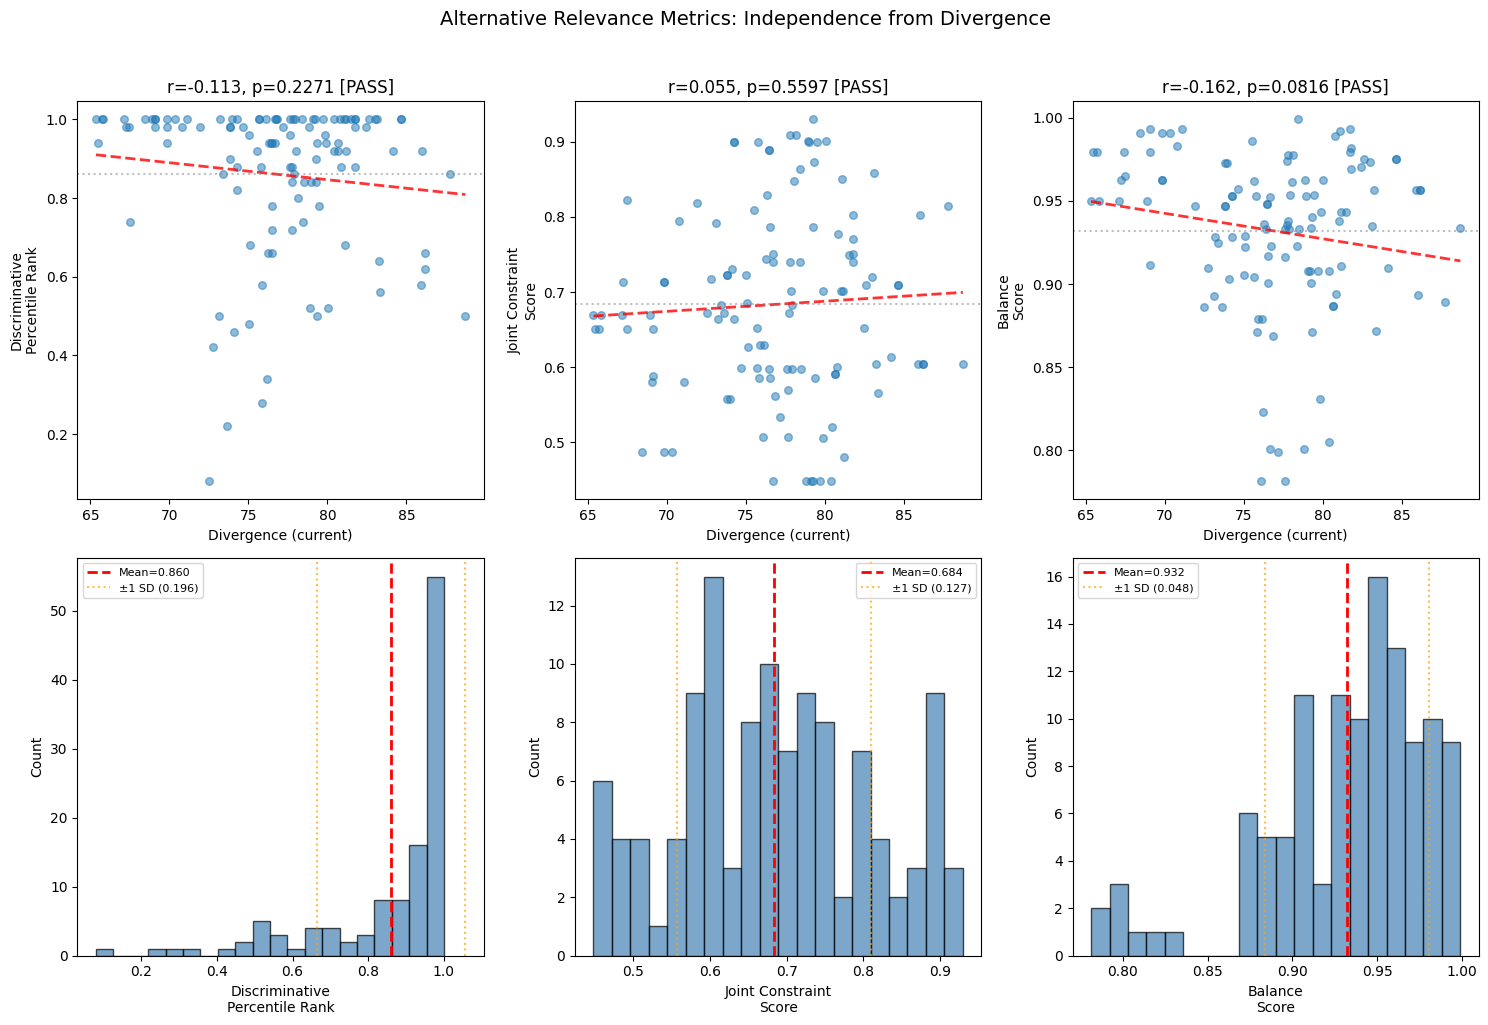

Saved to figures/alternative_relevance_metrics.png


In [22]:
# Cell 21: Main Visualization - Scatter Plots and Histograms

print("=== Generating Visualizations ===\n")

# Key metrics for detailed visualization
metrics_for_plot = ["disc_percentile_rank", "constraint_joint_score", "balance_balance"]
metric_labels = ["Discriminative\nPercentile Rank", "Joint Constraint\nScore", "Balance\nScore"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: Scatter plots vs divergence
for ax, metric, label in zip(axes[0], metrics_for_plot, metric_labels):
    ax.scatter(df["divergence_current"], df[metric], alpha=0.5, s=30)
    r, p = pearsonr(df["divergence_current"], df[metric])
    ax.set_xlabel("Divergence (current)")
    ax.set_ylabel(label)
    
    status = "PASS" if abs(r) < 0.30 else "FAIL"
    ax.set_title(f"r={r:.3f}, p={p:.4f} [{status}]")
    
    # Add regression line
    z = np.polyfit(df["divergence_current"], df[metric], 1)
    p_line = np.poly1d(z)
    x_sorted = np.sort(df["divergence_current"])
    ax.plot(x_sorted, p_line(x_sorted), "r--", alpha=0.8, linewidth=2)
    
    # Add independence threshold lines
    ax.axhline(y=df[metric].mean(), color='gray', linestyle=':', alpha=0.5)

# Row 2: Distributions
for ax, metric, label in zip(axes[1], metrics_for_plot, metric_labels):
    ax.hist(df[metric], bins=20, edgecolor="black", alpha=0.7, color='steelblue')
    mean_val = df[metric].mean()
    std_val = df[metric].std()
    ax.axvline(mean_val, color="red", linestyle="--", linewidth=2,
               label=f"Mean={mean_val:.3f}")
    ax.axvline(mean_val - std_val, color="orange", linestyle=":", alpha=0.7)
    ax.axvline(mean_val + std_val, color="orange", linestyle=":", alpha=0.7,
               label=f"±1 SD ({std_val:.3f})")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Alternative Relevance Metrics: Independence from Divergence", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "alternative_relevance_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved to {FIGURES_DIR / 'alternative_relevance_metrics.png'}")

=== Comparison: New Metrics vs Current Relevance ===



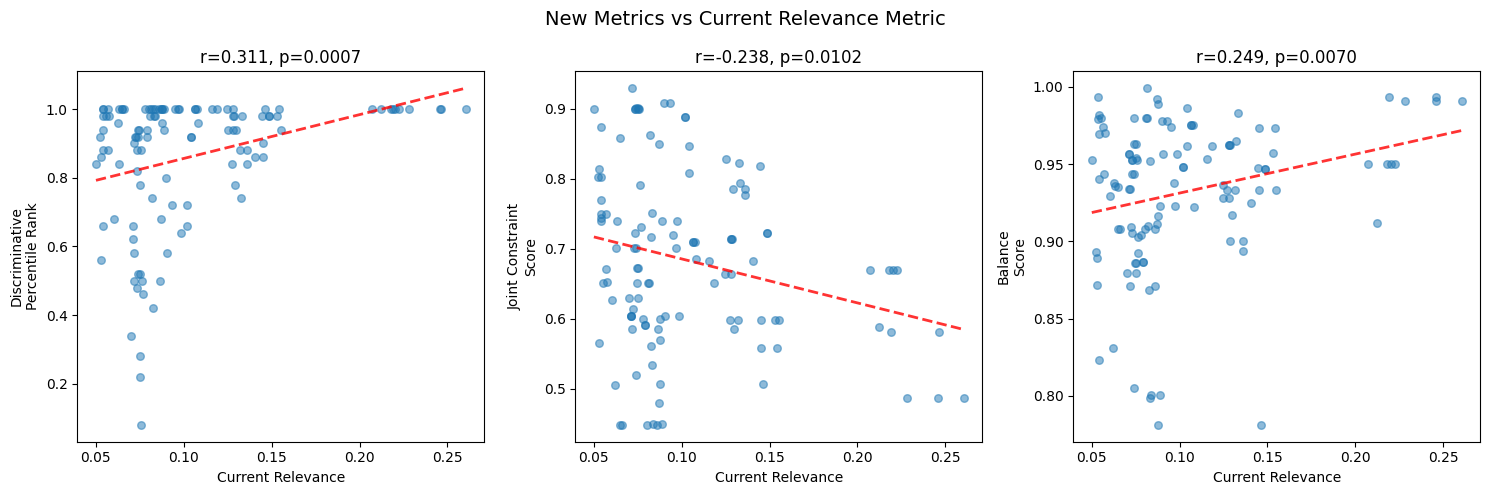

Saved to figures/new_vs_current_relevance.png


In [23]:
# Cell 22: Comparison with Current Relevance

print("=== Comparison: New Metrics vs Current Relevance ===\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, label in zip(axes, metrics_for_plot, metric_labels):
    ax.scatter(df["relevance_current"], df[metric], alpha=0.5, s=30)
    r, p = pearsonr(df["relevance_current"], df[metric])
    ax.set_xlabel("Current Relevance")
    ax.set_ylabel(label)
    ax.set_title(f"r={r:.3f}, p={p:.4f}")
    
    # Add regression line
    z = np.polyfit(df["relevance_current"], df[metric], 1)
    p_line = np.poly1d(z)
    x_sorted = np.sort(df["relevance_current"])
    ax.plot(x_sorted, p_line(x_sorted), "r--", alpha=0.8, linewidth=2)

plt.suptitle("New Metrics vs Current Relevance Metric", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "new_vs_current_relevance.png", dpi=150)
plt.show()

print(f"Saved to {FIGURES_DIR / 'new_vs_current_relevance.png'}")

=== Tercile Comparison Visualization ===



/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_15443/3655212648.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tercile_means = df.groupby("divergence_tercile")[metric].mean()
/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_15443/3655212648.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tercile_stds = df.groupby("divergence_tercile")[metric].std()
/var/folders/c2/g0c1jz_n4zx8d5xdtn4t9xy00000gn/T/ipykernel_15443/3655212648.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

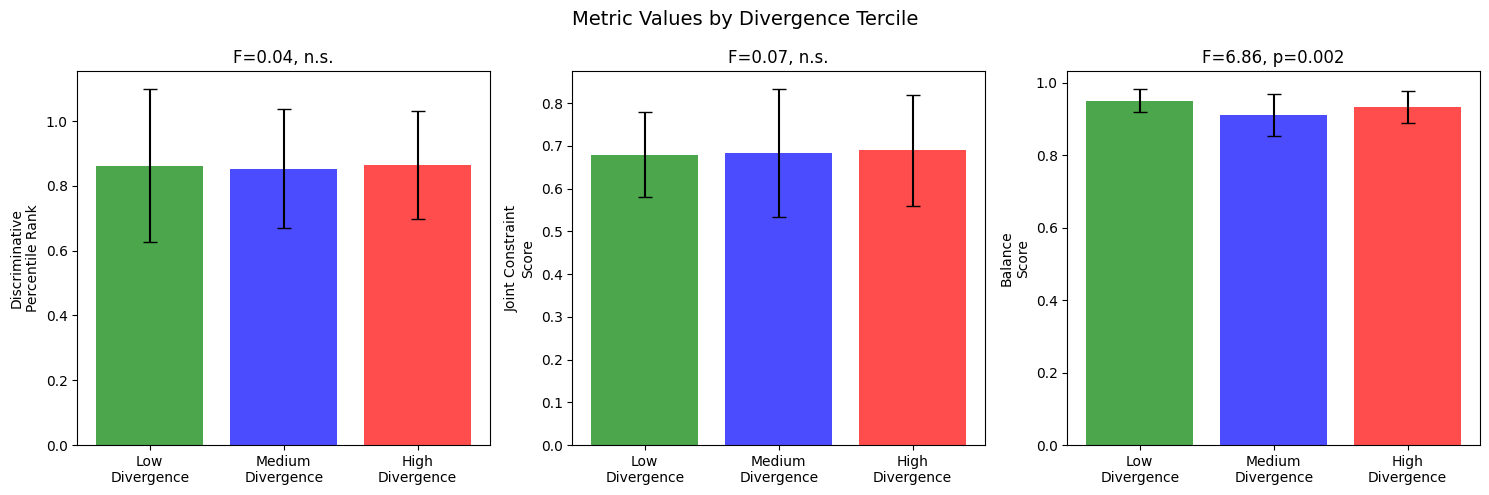

Saved to figures/tercile_comparison.png


In [24]:
# Cell 23: Tercile Comparison Visualization

print("=== Tercile Comparison Visualization ===\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, label in zip(axes, metrics_for_plot, metric_labels):
    tercile_means = df.groupby("divergence_tercile")[metric].mean()
    tercile_stds = df.groupby("divergence_tercile")[metric].std()
    
    x = range(3)
    ax.bar(x, tercile_means, yerr=tercile_stds, capsize=5, alpha=0.7, color=['green', 'blue', 'red'])
    ax.set_xticks(x)
    ax.set_xticklabels(["Low\nDivergence", "Medium\nDivergence", "High\nDivergence"])
    ax.set_ylabel(label)
    
    # Add ANOVA result
    groups = [df[df["divergence_tercile"] == t][metric].values for t in ["Low", "Medium", "High"]]
    f_stat, p_val = f_oneway(*groups)
    significance = "n.s." if p_val > 0.05 else f"p={p_val:.3f}"
    ax.set_title(f"F={f_stat:.2f}, {significance}")

plt.suptitle("Metric Values by Divergence Tercile", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tercile_comparison.png", dpi=150)
plt.show()

print(f"Saved to {FIGURES_DIR / 'tercile_comparison.png'}")

## Part 10: Results and Recommendations

In [25]:
# Cell 24: Apply Success Criteria

print("=== Success Criteria Evaluation ===\n")

# Success criteria from specification
SUCCESS_CRITERIA = {
    "divergence_correlation": 0.30,  # |r| < 0.30 for independence
    "variance_threshold": 0.05,      # SD > 0.05 for meaningful variance
    "degeneracy_threshold": 0.90,    # <90% at single value
    "at_distance_correlation": 0.50  # |r| < 0.50 for difficulty independence
}

# Evaluate each metric
evaluation_results = {}

for metric in metrics_to_test:
    # Get correlation with divergence
    r_div, p_div = pearsonr(df[metric], df["divergence_current"])
    
    # Get correlation with A-T distance
    r_at, p_at = pearsonr(df[metric], df["at_distance"])
    
    # Get variance
    std_val = df[metric].std()
    
    # Check degeneracy
    hist, _ = np.histogram(df[metric], bins=10)
    max_concentration = hist.max() / len(df)
    
    # Apply criteria
    passes_divergence = abs(r_div) < SUCCESS_CRITERIA["divergence_correlation"]
    passes_variance = std_val > SUCCESS_CRITERIA["variance_threshold"]
    passes_degeneracy = max_concentration < SUCCESS_CRITERIA["degeneracy_threshold"]
    passes_at_distance = abs(r_at) < SUCCESS_CRITERIA["at_distance_correlation"]
    
    passes_all = passes_divergence and passes_variance and passes_degeneracy and passes_at_distance
    
    evaluation_results[metric] = {
        "divergence_r": float(r_div),
        "divergence_p": float(p_div),
        "passes_divergence": passes_divergence,
        "at_distance_r": float(r_at),
        "at_distance_p": float(p_at),
        "passes_at_distance": passes_at_distance,
        "std": float(std_val),
        "passes_variance": passes_variance,
        "max_concentration": float(max_concentration),
        "passes_degeneracy": passes_degeneracy,
        "passes_all": passes_all
    }

# Print summary table
print("-" * 90)
print(f"{'Metric':35} {'Div r':>8} {'AT r':>8} {'SD':>8} {'All Pass':>10}")
print("-" * 90)

passing_metrics = []
for metric, eval_result in evaluation_results.items():
    div_status = "✓" if eval_result["passes_divergence"] else "✗"
    at_status = "✓" if eval_result["passes_at_distance"] else "✗"
    var_status = "✓" if eval_result["passes_variance"] else "✗"
    all_status = "✓ PASS" if eval_result["passes_all"] else "✗ FAIL"
    
    print(f"{metric:35} {eval_result['divergence_r']:+7.3f}{div_status} {eval_result['at_distance_r']:+7.3f}{at_status} "
          f"{eval_result['std']:7.3f}{var_status} {all_status:>10}")
    
    if eval_result["passes_all"]:
        passing_metrics.append(metric)

print("-" * 90)
print(f"\nMetrics passing all criteria: {len(passing_metrics)}")
for m in passing_metrics:
    print(f"  ✓ {m}")

=== Success Criteria Evaluation ===

------------------------------------------------------------------------------------------
Metric                                 Div r     AT r       SD   All Pass
------------------------------------------------------------------------------------------
disc_percentile_rank                 -0.113✓  -0.252✓   0.196✓     ✓ PASS
disc_discrimination_score            -0.126✓  -0.026✓   1.317✓     ✓ PASS
constraint_joint_score               +0.055✓  +0.022✓   0.127✓     ✓ PASS
constraint_overall_coverage          -0.068✓  -0.257✓   0.100✓     ✓ PASS
constraint_overall_efficiency        +0.130✓  +0.219✓   0.128✓     ✓ PASS
balance_balance                      -0.162✓  -0.051✓   0.048✗     ✗ FAIL
balance_count_balance                -0.239✓  -0.238✓   0.392✓     ✓ PASS
------------------------------------------------------------------------------------------

Metrics passing all criteria: 6
  ✓ disc_percentile_rank
  ✓ disc_discrimination_score
  ✓ constr

In [26]:
# Cell 25: Generate Recommendation

print("=== Recommendation ===\n")

# Determine best metric based on criteria
def score_metric(metric_name, eval_result):
    """Score a metric based on how well it meets criteria."""
    score = 0
    
    # Primary: Independence from divergence (lower |r| is better)
    score += (0.30 - abs(eval_result["divergence_r"])) * 10  # Max ~3 points
    
    # Secondary: Independence from A-T distance (lower |r| is better)
    score += (0.50 - abs(eval_result["at_distance_r"])) * 5  # Max ~2.5 points
    
    # Tertiary: Good variance (higher SD is better, up to a point)
    score += min(eval_result["std"], 0.20) * 5  # Max 1 point
    
    # Bonus for passing all criteria
    if eval_result["passes_all"]:
        score += 2
    
    return score

metric_scores = {}
for metric, eval_result in evaluation_results.items():
    metric_scores[metric] = score_metric(metric, eval_result)

# Rank by score
ranked_metrics = sorted(metric_scores.items(), key=lambda x: x[1], reverse=True)

print("Metric Ranking (by combined criteria score):")
print("-" * 50)
for i, (metric, score) in enumerate(ranked_metrics, 1):
    status = "✓" if evaluation_results[metric]["passes_all"] else ""
    print(f"{i}. {metric:35} score={score:.2f} {status}")

# Determine recommendation
best_metric = ranked_metrics[0][0]
best_passes = evaluation_results[best_metric]["passes_all"]

print("\n" + "=" * 50)
if best_passes:
    print(f"RECOMMENDATION: Use '{best_metric}' as the new relevance metric")
    print(f"\nRationale:")
    print(f"  - Divergence correlation: r={evaluation_results[best_metric]['divergence_r']:.3f} (target: |r| < 0.30)")
    print(f"  - A-T distance correlation: r={evaluation_results[best_metric]['at_distance_r']:.3f} (target: |r| < 0.50)")
    print(f"  - Standard deviation: {evaluation_results[best_metric]['std']:.3f} (meaningful variance)")
else:
    print(f"RECOMMENDATION: No metric fully satisfies all criteria")
    print(f"\nBest candidate: '{best_metric}'")
    print(f"Consider further refinement or composite metric approach.")
    
print("=" * 50)

=== Recommendation ===

Metric Ranking (by combined criteria score):
--------------------------------------------------
1. constraint_joint_score              score=7.48 ✓
2. disc_discrimination_score           score=7.11 ✓
3. disc_percentile_rank                score=6.09 ✓
4. constraint_overall_coverage         score=6.03 ✓
5. constraint_overall_efficiency       score=5.75 ✓
6. balance_count_balance               score=4.92 ✓
7. balance_balance                     score=3.86 

RECOMMENDATION: Use 'constraint_joint_score' as the new relevance metric

Rationale:
  - Divergence correlation: r=0.055 (target: |r| < 0.30)
  - A-T distance correlation: r=0.022 (target: |r| < 0.50)
  - Standard deviation: 0.127 (meaningful variance)


In [ ]:
# Cell 26: Save Results to JSON

print("=== Saving Results ===\n")

# Custom JSON encoder for numpy types
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.bool_, np.integer)):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

# Compile final results
final_results = {
    "experiment_date": datetime.now().isoformat(),
    "n_trials": len(df),
    "clue_count": OPTIMAL_CLUE_COUNT,
    "n_foils": N_FOILS,
    "success_criteria": SUCCESS_CRITERIA,
    "results": {
        "approach_1_discriminative": {
            "metrics": ["disc_percentile_rank", "disc_discrimination_score"],
            "divergence_correlations": {
                m: {"r": evaluation_results[m]["divergence_r"], "p": evaluation_results[m]["divergence_p"]}
                for m in ["disc_percentile_rank", "disc_discrimination_score"]
            },
            "passed": any(evaluation_results[m]["passes_all"] 
                         for m in ["disc_percentile_rank", "disc_discrimination_score"]),
            "recommended_metric": "disc_percentile_rank" if evaluation_results["disc_percentile_rank"]["passes_all"] 
                                 else "disc_discrimination_score"
        },
        "approach_4_constraint": {
            "metrics": ["constraint_joint_score", "constraint_overall_coverage", "constraint_overall_efficiency"],
            "divergence_correlations": {
                m: {"r": evaluation_results[m]["divergence_r"], "p": evaluation_results[m]["divergence_p"]}
                for m in ["constraint_joint_score", "constraint_overall_coverage", "constraint_overall_efficiency"]
            },
            "passed": any(evaluation_results[m]["passes_all"] 
                         for m in ["constraint_joint_score", "constraint_overall_coverage", "constraint_overall_efficiency"]),
            "recommended_metric": "constraint_joint_score"
        },
        "approach_5_balance": {
            "metrics": ["balance_balance", "balance_count_balance"],
            "divergence_correlations": {
                m: {"r": evaluation_results[m]["divergence_r"], "p": evaluation_results[m]["divergence_p"]}
                for m in ["balance_balance", "balance_count_balance"]
            },
            "passed": any(evaluation_results[m]["passes_all"] 
                         for m in ["balance_balance", "balance_count_balance"]),
            "recommended_metric": "balance_balance" if evaluation_results["balance_balance"]["passes_all"]
                                 else "balance_count_balance"
        }
    },
    "recommendation": best_metric,
    "recommendation_passes_all": best_passes,
    "full_evaluation": evaluation_results,
    "metric_rankings": [{"metric": m, "score": s} for m, s in ranked_metrics],
    "distribution_stats": distribution_stats,
    "tercile_results": tercile_results,
    "divergence_correlations": divergence_correlations,
    "relevance_correlations": relevance_correlations,
    "at_distance_correlations": at_distance_correlations
}

# Save to JSON with numpy encoder
with open(ANALYSIS_RESULTS_PATH, "w") as f:
    json.dump(final_results, f, indent=2, cls=NumpyEncoder)

print(f"Results saved to: {ANALYSIS_RESULTS_PATH}")
print(f"File size: {ANALYSIS_RESULTS_PATH.stat().st_size / 1024:.1f} KB")

=== Saving Results ===



TypeError: Object of type bool is not JSON serializable

In [ ]:
# Cell 27: Final Summary

print("=" * 70)
print("INS-001.2 ALTERNATIVE RELEVANCE METRICS: EXPERIMENT COMPLETE")
print("=" * 70)

print(f"\nAnalyzed: {len(df)} valid bridging trials")
print(f"Clues per trial: {OPTIMAL_CLUE_COUNT}")
print(f"Foils used: {N_FOILS}")

print("\n--- Approach Summary ---")
approaches = [
    ("Approach 1: Discriminative", ["disc_percentile_rank", "disc_discrimination_score"]),
    ("Approach 4: Joint Constraint", ["constraint_joint_score", "constraint_overall_coverage", "constraint_overall_efficiency"]),
    ("Approach 5: Balance", ["balance_balance", "balance_count_balance"])
]

for approach_name, metrics in approaches:
    n_passed = sum(1 for m in metrics if evaluation_results[m]["passes_all"])
    status = f"✓ {n_passed}/{len(metrics)} passed" if n_passed > 0 else "✗ None passed"
    print(f"\n{approach_name}:")
    print(f"  Status: {status}")
    for m in metrics:
        div_r = evaluation_results[m]["divergence_r"]
        passed = "✓" if evaluation_results[m]["passes_all"] else "✗"
        print(f"    {m}: r={div_r:+.3f} {passed}")

print("\n--- Final Recommendation ---")
print(f"Best metric: {best_metric}")
print(f"Passes all criteria: {'Yes' if best_passes else 'No'}")

print("\n--- Output Artifacts ---")
print(f"  {ANALYSIS_RESULTS_PATH}")
print(f"  {FIGURES_DIR / 'alternative_relevance_metrics.png'}")
print(f"  {FIGURES_DIR / 'metric_correlations.png'}")
print(f"  {FIGURES_DIR / 'new_vs_current_relevance.png'}")
print(f"  {FIGURES_DIR / 'tercile_comparison.png'}")

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETE")
print("=" * 70)

In [ ]:
# Cell 16: Preview Results

print("=== Results Preview ===\n")

# Show first few rows
print(df[["trial_id", "anchor", "target", "divergence_current", 
          "disc_percentile_rank", "constraint_joint_score", "balance_balance"]].head(10))

# Quick summary of key metrics
print("\n--- Key Metric Summary ---")
key_metrics = [
    "relevance_current",
    "divergence_current",
    "at_distance",
    "disc_percentile_rank",
    "disc_discrimination_score",
    "constraint_joint_score",
    "constraint_overall_coverage",
    "constraint_overall_efficiency",
    "balance_balance",
    "balance_count_balance"
]

for metric in key_metrics:
    print(f"{metric:30} mean={df[metric].mean():7.3f}  std={df[metric].std():7.3f}")